<a href="https://colab.research.google.com/github/Bernicechizaram/Streaming-Stock-Analysis/blob/main/Netflix_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

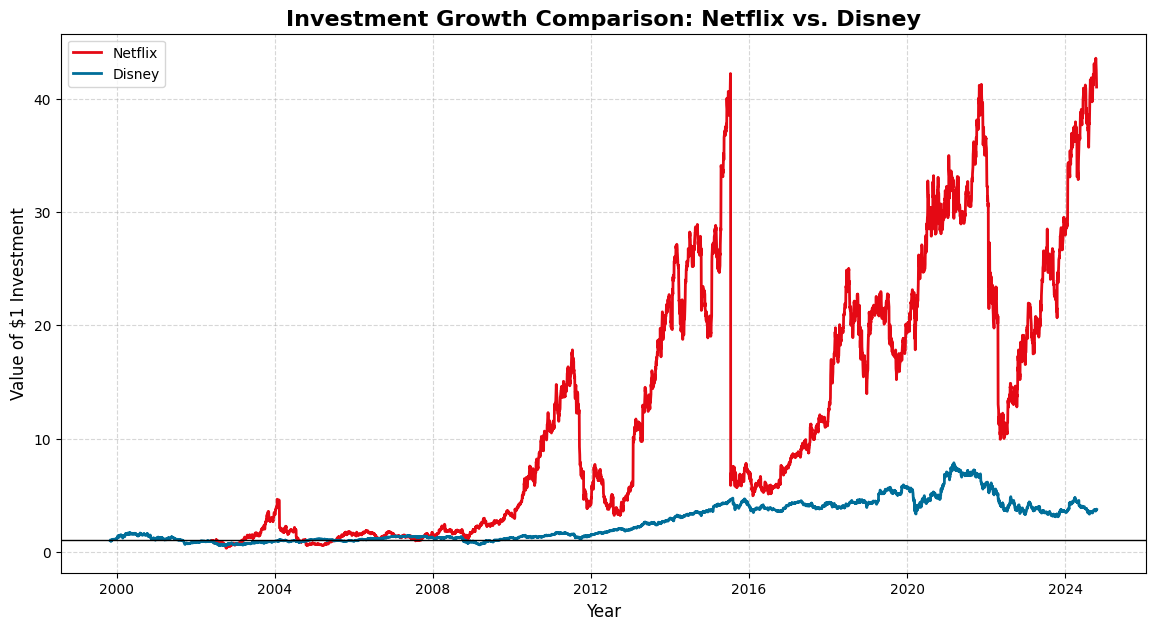

In [11]:
import matplotlib.pyplot as plt

# 1. Calculate Cumulative Return using 'Close Price'
# Formula: (Current Price / Price on the very first day)
nflx['Cumulative Return'] = nflx['Close Price'] / nflx['Close Price'].iloc[0]
dis['Cumulative Return'] = dis['Close Price'] / dis['Close Price'].iloc[0]

# 2. Plotting the Comparison
plt.figure(figsize=(14, 7))

# Plotting lines
plt.plot(nflx.index, nflx['Cumulative Return'], label='Netflix', color='#E50914', linewidth=2)
plt.plot(dis.index, dis['Cumulative Return'], label='Disney', color='#006E99', linewidth=2)

# Styling the Chart
plt.title('Investment Growth Comparison: Netflix vs. Disney', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Value of $1 Investment', fontsize=12)
plt.legend(loc='upper left')
plt.grid(visible=True, linestyle='--', alpha=0.5)

# Adding a horizontal line at 1.0 to show the starting point
plt.axhline(1, color='black', lw=1, linestyle='-')

plt.show()

In [7]:
from google.colab import files
import zipfile
import io
import os

# Upload ZIP file
uploaded = files.upload()

# Automatically get the uploaded file name
zip_filename = next(iter(uploaded))

# Unzip the file into /content/
with zipfile.ZipFile(io.BytesIO(uploaded[zip_filename]), 'r') as zip_ref:
    zip_ref.extractall('/content/')

# List the extracted files
print("Files extracted to /content/:")
print(os.listdir('/content/'))


Saving archive (3).zip to archive (3) (3).zip
Files extracted to /content/:
['.config', 'NFLX_stock_price.csv', 'archive (3) (1).zip', 'archive (3) (2).zip', 'DIS_stock_price.csv', 'DIS_stock_split.csv', 'NFLX_stock_split.csv', 'archive (3).zip', 'archive (3) (3).zip', 'sample_data']


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the CSV files
# Note: I'm using the exact names from the list
nflx = pd.read_csv('NFLX_stock_price.csv')
dis = pd.read_csv('DIS_stock_price.csv')

# 2. Convert Date and set as Index
nflx['Date'] = pd.to_datetime(nflx['Date'])
dis['Date'] = pd.to_datetime(dis['Date'])

nflx.set_index('Date', inplace=True)
dis.set_index('Date', inplace=True)

# 3. Sort them so the timeline is perfect
nflx.sort_index(inplace=True)
dis.sort_index(inplace=True)

print("Success! Data loaded and sorted by date.")
print(f"Netflix range: {nflx.index.min()} to {nflx.index.max()}")

Success! Data loaded and sorted by date.
Netflix range: 2002-05-23 00:00:00 to 2024-10-17 00:00:00


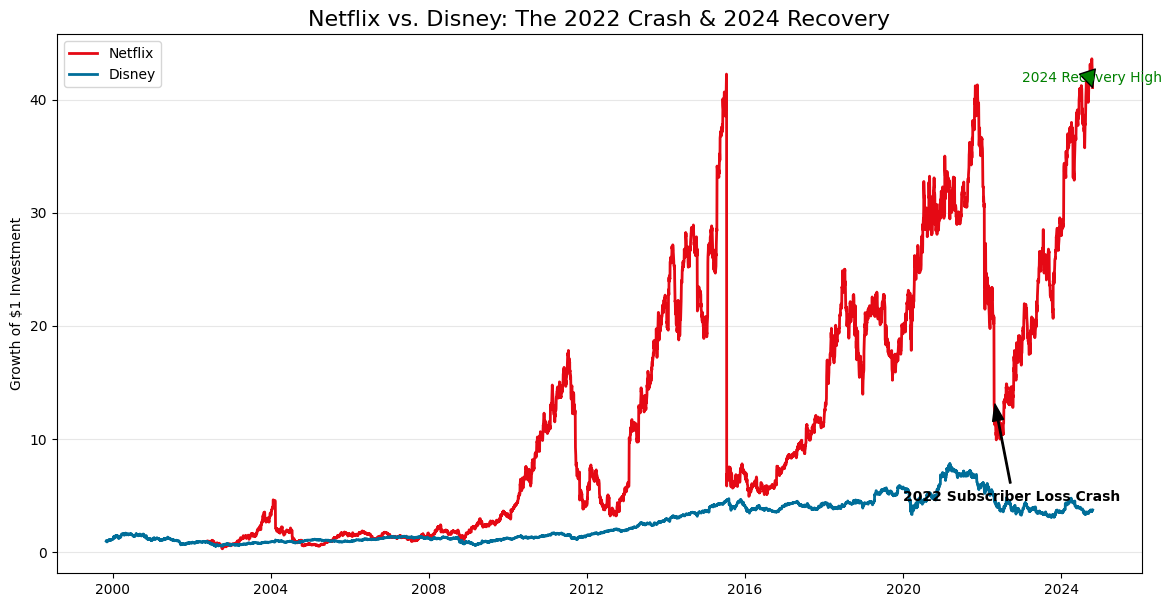

In [12]:
plt.figure(figsize=(14, 7))

# Plotting the Cumulative Return again
plt.plot(nflx.index, nflx['Cumulative Return'], label='Netflix', color='#E50914', linewidth=2)
plt.plot(dis.index, dis['Cumulative Return'], label='Disney', color='#006E99', linewidth=2)

# Adding the Annotation for the 2022 Crash
# We use 'xy' to point to the date and 'xytext' to place the label
plt.annotate('2022 Subscriber Loss Crash',
             xy=(pd.Timestamp('2022-04-20'), nflx.loc['2022-04-20', 'Cumulative Return']),
             xytext=(pd.Timestamp('2020-01-01'), 4.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, fontweight='bold', color='black')

# Adding a label for the 2024 All-Time High
plt.annotate('2024 Recovery High',
             xy=(nflx.index[-1], nflx['Cumulative Return'].iloc[-1]),
             xytext=(pd.Timestamp('2023-01-01'), nflx['Cumulative Return'].iloc[-1] + 0.5),
             arrowprops=dict(facecolor='green', shrink=0.05, width=1),
             fontsize=10, color='green')

plt.title('Netflix vs. Disney: The 2022 Crash & 2024 Recovery', fontsize=16)
plt.ylabel('Growth of $1 Investment')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [13]:
# 1. Reset the index so 'Date' becomes a regular column
nflx_export = nflx.reset_index()
dis_export = dis.reset_index()

# 2. Add a 'Company' label to each
nflx_export['Company'] = 'Netflix'
dis_export['Company'] = 'Disney'

# 3. Combine them into one "Master" table
combined_stocks = pd.concat([nflx_export, dis_export], ignore_index=True)

# 4. Export to CSV
combined_stocks.to_csv('Streaming_Stocks_Tableau.csv', index=False)

print("File Created: Streaming_Stocks_Tableau.csv")

File Created: Streaming_Stocks_Tableau.csv


In [15]:
from google.colab import files

# This will trigger an automatic download in your browser
files.download('Streaming_Stocks_Tableau.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>